In [2]:
import os
new_dir = "/home/jingqi"
os.chdir(new_dir)
os.getcwd()

'/home/jingqi'

In [3]:
import scipy
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
import scanpy as sc
file_path_adta = "isoforms/adata_thresholded.h5ad"
adata = sc.read_h5ad(file_path_adta)

In [5]:
import pandas as pd
file_path_gene = 'RNALocateV3.0/Data/FIMO/a_genewise.csv'
df = pd.read_csv(file_path_gene)

In [19]:
adata.obs

,sample,dataset,devtime,location,n_genes_by_counts,total_counts,total_counts_ERCC,pct_counts_ERCC,doublet_scores,predicted_doublets,...,SatGlia,SC,BCC,conflict,nmSC,tSC,mSC,assignments,Hub,Hub_leiden
E24_SS2_15_0073,E24,SS2_15_0073,E12.5,Cranial,10335,483881.656250,42552.0,8.793886,0.163418,False,...,False,False,False,False,False,False,False,none,True,True
G2_SS2_15_0073,G2,SS2_15_0073,E12.5,Cranial,8101,231835.359375,24521.0,10.576902,0.125778,False,...,False,False,False,False,False,False,False,none,True,True
M17_SS2_15_0073,M17,SS2_15_0073,E12.5,Cranial,11109,447859.625000,28720.0,6.412724,0.055556,False,...,False,False,False,False,False,False,False,none,True,True
M21_SS2_15_0073,M21,SS2_15_0073,E12.5,Cranial,10845,576399.687500,49646.0,8.613121,0.133940,False,...,False,False,False,True,False,False,False,none,False,False
L24_SS2_15_0073,L24,SS2_15_0073,E12.5,Cranial,9310,394860.406250,35324.0,8.945947,0.372093,False,...,False,False,False,False,False,False,False,Sensory,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A15_SS2_19_372,A15,SS2_19_372,E10.5,Trunk,11634,354191.000000,56.0,0.015811,0.152639,False,...,False,False,False,False,False,False,False,Sensory,False,False
D24_SS2_19_372,D24,SS2_19_372,E10.5,Trunk,11949,256256.546875,39.0,0.015219,0.108108,False,...,False,False,False,False,False,False,False,NCC,False,False
I18_SS2_19_372,I18,SS2_19_372,E10.5,Trunk,12004,302828.500000,65.0,0.021464,0.138298,False,...,False,False,False,False,False,False,False,NCC,False,False
H24_SS2_19_372,H24,SS2_19_372,E10.5,Trunk,11403,241807.250000,62.0,0.025640,0.261339,False,...,False,False,False,False,False,False,False,Sensory,False,False


In [21]:
adata.var

,transcript_type,tag,level,transcript_support_level,annot_remark,gene,transcript,ERCC,n_cells_by_counts,mean_counts,...,n_cells,m,v,n_obs,res,lp,lpa,qv,highly_variable,sum_gex
ENSMUST00000151521.3,lncRNA,TAGENE,2.0,1.0,['CLS3 project'],0610009E02Rik,0610009E02Rik-203,False,2242,1.467521,...,1293,-4.982605,-6.950791,1293.0,0.417252,-3.087365e+01,-27.717662,1.119186,True,4768.07373
ENSMUST00000139144.4,lncRNA,TAGENE,2.0,2.0,"['Assembled from PacBio CLS3 reads', 'CLS3 pro...",0610009E02Rik,0610009E02Rik-202,False,16,0.003809,...,6,-11.591813,-15.621390,6.0,-0.159712,-5.544454e-01,0.000000,0.996921,False,4768.07373
ENSMUST00000247119.2,lncRNA,TAGENE,2.0,nan,"['Assembled from PacBio CLS3 reads', 'CLS3 pro...",0610009E02Rik,0610009E02Rik-206,False,314,0.143611,...,162,-7.506163,-9.938689,162.0,0.578556,-8.943692e+00,-6.900886,1.057011,True,4768.07373
ENSMUST00000322045.1,lncRNA,TAGENE,2.0,nan,['CLS3 project'],0610009E02Rik,0610009E02Rik-218,False,16,0.006617,...,9,-10.563974,-12.999599,9.0,0.864849,-2.236367e+00,-0.909736,1.019049,False,4768.07373
ENSMUST00000246989.2,lncRNA,TAGENE,2.0,nan,"['Assembled from PacBio CLS3 reads', 'CLS3 pro...",0610009E02Rik,0610009E02Rik-204,False,16,0.012020,...,9,-9.870461,-12.505523,9.0,0.489764,-1.433390e+00,-0.349531,1.010780,False,4768.07373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUST00000106100.9,protein_coding,CCDS,2.0,1.0,Unknown,Zzz3,Zzz3-202,False,2326,2.258497,...,1220,-4.914307,-6.797331,1220.0,0.485407,-3.863515e+01,-35.186850,1.135189,True,11450.12207
ENSMUST00000150802.8,protein_coding_CDS_not_defined,Unknown,2.0,3.0,Unknown,Zzz3,Zzz3-207,False,1019,0.230724,...,496,-7.090480,-10.597734,496.0,-0.562858,-2.423873e-10,0.000000,0.907112,False,11450.12207
ENSMUST00000089982.11,protein_coding,CCDS,2.0,1.0,['NP_001274068'],Zzz3,Zzz3-201,False,5414,9.671398,...,2897,-3.354754,-5.445978,2897.0,0.022700,-1.306925e+00,-0.280270,1.009227,False,11450.12207
ENSMUST00000198468.2,retained_intron,Unknown,2.0,nan,Unknown,Zzz3,Zzz3-209,False,820,0.648468,...,432,-5.977411,-7.773703,432.0,0.867247,-4.247119e+01,-38.885022,1.142526,True,11450.12207


### check the expression profile in each cluster

In [24]:
target_transcripts = df['Transcript'].tolist()
gene_map = df[['Gene', 'Transcript']]

# Subset adata to ONLY these transcripts first (makes calculations faster)
valid_transcripts = [t for t in target_transcripts if t in adata.var_names]
adata_subset = adata[:, valid_transcripts].copy()

cluster_key = 'assignments' 

# Calculate "Percent Expressed" per cluster
# This creates a DataFrame where Rows = Transcripts, Columns = Clusters
pct_expressed = {}

for cluster in adata_subset.obs[cluster_key].unique():
    # Get cells in this cluster
    cells_in_cluster = adata_subset[adata_subset.obs[cluster_key] == cluster]
    
    # Calculate fraction of cells with counts > 0
    # (Using .X directly. If sparse, we use .getnnz or similar, but dense is easier to read here)
    if scipy.sparse.issparse(cells_in_cluster.X):
        # Sparse matrix calculation
        expressed_counts = (cells_in_cluster.X > 0).sum(axis=0).A1
    else:
        # Dense matrix calculation
        expressed_counts = (cells_in_cluster.X > 0).sum(axis=0)
        
    pct_expressed[cluster] = expressed_counts / cells_in_cluster.n_obs

# Convert to DataFrame for easy viewing
df_pct = pd.DataFrame(pct_expressed, index=adata_subset.var_names)

# Currently, 'Transcript' is the index (row labels), movee it it as a proper column.
df_with_transcripts = df_pct.reset_index()
# Ensure the new column is named 'Transcript' (sometimes it's named 'index' by default)
df_with_transcripts = df_with_transcripts.rename(columns={'index': 'Transcript'})

# 'how=left' ensures we keep all rows from the results table
df_final = pd.merge(df_with_transcripts, gene_map, on='Transcript', how='left')

# put 'Gene' and 'Transcript' first, followed by all other columns (the clusters)
cols = ['Gene', 'Transcript'] + [c for c in df_final.columns if c not in ['Gene', 'Transcript']]
df_final = df_final[cols]

# Look at the result!
print("Percent of cells expressing each transcript per cluster:")
# Save to CSV to inspect in Excel
df_final.to_csv('RNALocateV3.0/Data/Validation/transcript_expression_cluster.csv')

Percent of cells expressing each transcript per cluster:


### filtering by expression percentage

In [40]:
file_path = 'RNALocateV3.0/Data/Validation/transcript_expression_cluster.csv'
df = pd.read_csv(file_path)

# Store original counts
original_genes = df['Gene'].nunique()
original_transcripts = len(df)

# Remove the first column (Index) and the 'none' column
df = df.iloc[:, 1:] 
if 'none' in df.columns:
    df = df.drop(columns=['none'])

# Identify numeric columns
lable_cols = ['Gene', 'Transcript']
cluster_cols = [c for c in df.columns if c not in lable_cols]

# This creates a Series with the mean of each cluster
column_means = df[cluster_cols].mean()

# Define the threshold list
thresholds = column_means * 1

# Condition: Discard if ALL numbers in the row are smaller than the threshold
mask_keep_rows = (df[cluster_cols] >= thresholds).any(axis=1)

df_filtered_rows = df[mask_keep_rows].copy()

# If a gene only has one row (one transcript is left), also discard it
gene_counts = df_filtered_rows['Gene'].value_counts()
genes_to_keep = gene_counts[gene_counts > 1].index

# Filter the dataframe
df_final = df_filtered_rows[df_filtered_rows['Gene'].isin(genes_to_keep)].copy()
df_final.to_csv('RNALocateV3.0/Data/Validation/transcript_filtered.csv', index=False)

# Report the results
final_genes = df_final['Gene'].nunique()
final_transcripts = len(df_final)

print(f"Processing Complete.")
print(f"Original: {original_genes} genes, {original_transcripts} transcripts")
print(f"Final:    {final_genes} genes, {final_transcripts} transcripts")

Processing Complete.
Original: 432 genes, 1641 transcripts
Final:    372 genes, 1073 transcripts


### test to also threshold by specificity

In [ ]:
def gini(array):
    """Calculate the Gini coefficient of a numpy array."""
    # Ensure flattened, sorted, and non-negative
    array = array.flatten().astype(float)
    if np.amin(array) < 0:
        array -= np.amin(array)
        
    array += 1e-12 # Small epsilon to avoid div by zero
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

In [41]:
file_path = 'RNALocateV3.0/Data/Validation/transcript_expression_cluster.csv'
df = pd.read_csv(file_path)

original_genes = df['Gene'].nunique()
original_transcripts = len(df)

# Preprocessing (Remove index and 'none' column)
df = df.iloc[:, 1:] 
if 'none' in df.columns:
    df = df.drop(columns=['none'])

# Identify numeric columns
label_cols = ['Gene', 'Transcript']
cluster_cols = [c for c in df.columns if c not in label_cols]

#  Calculate Thresholds
# RULE1: Mean Threshold (Abundance)
column_means = df[cluster_cols].mean()
mean_thresholds = column_means * 1 

# RULE2: Gini Coefficient (Specificity/Pattern)
# Calculate Gini for every row
gini_values = df[cluster_cols].apply(lambda x: gini(x.values), axis=1)
gini_threshold = 0.8  # Higher requires more distinct pattern

# Apply Filters
pass_mean_mask = (df[cluster_cols] >= mean_thresholds).any(axis=1)

pass_gini_mask = gini_values >= gini_threshold

# "if at least one is met, keep it
keep_mask = pass_mean_mask | pass_gini_mask
keep_mask_hard = pass_mean_mask & pass_gini_mask

# Identify what is being discarded
fail_mean_mask = ~pass_mean_mask
fail_gini_mask = ~pass_gini_mask
fail_both_mask = fail_mean_mask & fail_gini_mask

df_filtered_rows = df[keep_mask].copy()

# Gene Filtering (Must have >= 2 transcripts)
gene_counts = df_filtered_rows['Gene'].value_counts()
genes_to_keep = gene_counts[gene_counts > 1].index
df_final = df_filtered_rows[df_filtered_rows['Gene'].isin(genes_to_keep)].copy()

# Reporting
final_genes = df_final['Gene'].nunique()
final_transcripts = len(df_final)

print("--- Filtering Statistics ---")
print(f"Total Transcripts Checked: {original_transcripts}")
print(f"  - Saved by Specificity: {fail_mean_mask.sum() - fail_both_mask.sum()}")
print(f"--------------------------------------------------")
print(f"Original: {original_genes} genes, {original_transcripts} transcripts")
print(f"Final:    {final_genes} genes, {final_transcripts} transcripts")

# Save Result
df_final.to_csv('RNALocateV3.0/Data/Validation/(test)transcript_filtered.csv', index=False)

--- Filtering Statistics ---
Total Transcripts Checked: 1641
  - Saved by Specificity: 50
--------------------------------------------------
Original: 432 genes, 1641 transcripts
Final:    378 genes, 1129 transcripts


### filtering by similarity

In [52]:
file_path = 'RNALocateV3.0/Data/Validation/transcript_filtered.csv'
df = pd.read_csv(file_path)

# Ensure these are the only non-numeric columns in your dataframe.
expression_cols = [c for c in df_final.columns if c not in ['Gene', 'Transcript']]

# Dictionary to store similarity scores for inspection later
gene_similarity_scores = {}
genes_to_discard = []

# Iterate through each gene
# use groupby to process one gene at a time
for gene, group in df.groupby('Gene'):

    mat = group[expression_cols].values
        
    # Calculate Cosine Similarity Matrix
    sim_matrix = cosine_similarity(mat)
 
    # We only need the upper triangle (k=1)
    upper_tri_indices = np.triu_indices_from(sim_matrix, k=1)
    pairwise_similarities = sim_matrix[upper_tri_indices]
    
    # Store the values (rounded for readability)
    gene_similarity_scores[gene] = np.round(pairwise_similarities, 3)

    # If ALL pairwise similarities are large, discard the gene.
    threshold = 0.6
    if np.all(pairwise_similarities > threshold):
        genes_to_discard.append(gene)

# Filter the DataFrame
df_final = df[~df['Gene'].isin(genes_to_discard)].copy()
df_final.to_csv('RNALocateV3.0/Data/Validation/transcript_2_filtered.csv', index=False)

# Report Results
print(f"Similarity Filtering Complete (Threshold > {threshold})")
print(f"--------------------------------------------------")
print(f"Genes checked:    {df['Gene'].nunique()}")
print(f"Transcripts before: {len(df)}")
print(f"Genes remaining:  {df_final['Gene'].nunique()}")
print(f"Transcripts after: {len(df_final)}")

# Optional: Inspect a few discarded genes to see their scores
if len(genes_to_discard) > 0:
    print("\nExample discarded genes and their similarity scores:")
    for g in genes_to_discard[:6]:
        print(f"  {g}: {gene_similarity_scores[g]}")

Similarity Filtering Complete (Threshold > 0.6)
--------------------------------------------------
Genes checked:    372
Transcripts before: 1073
Genes remaining:  27
Transcripts after: 107

Example discarded genes and their similarity scores:
  1700017B05Rik: [0.927]
  2510009E07Rik: [0.883]
  AI506816: [0.889]
  Abca3: [0.761]
  Adam12: [0.936]
  Adamts12: [0.976]


### Going back to localizations

In [55]:
file_path_backg = 'RNALocateV3.0/Data/FIMO/a_genewise.csv'
dbase = pd.read_csv(file_path_backg)
file_path_disti = 'RNALocateV3.0/Data/Validation/transcript_2_filtered.csv'
df = pd.read_csv(file_path_disti)

# Keep rows in df where the 'Transcript' is present in dbase
df_matched = dbase[dbase['Transcript'].isin(df['Transcript'])].copy()


# Identify all localization columns (e.g., Localization_1, Localization_2...)
loc_cols = [c for c in df_matched.columns if 'Localization' in c]
genes_with_diff_loc = []

for gene, group in df_matched.groupby('Gene'):
    # Select only the localization data
    loc_data = group[loc_cols]
    
    # drop_duplicates() reduces the dataframe to unique rows only.
    # If the length is > 1, it means there are at least 2 different localization patterns.
    if len(loc_data.drop_duplicates()) > 1:
        genes_with_diff_loc.append(gene)

# Apply the filter
df_final = df_matched[df_matched['Gene'].isin(genes_with_diff_loc)].copy()

output_path = 'RNALocateV3.0/Data/Validation/transcript_localization.csv'
df_final.to_csv(output_path, index=False)

print("done!")

done!


### Show the distribution

In [8]:
isoforms_1 = 'ENSMUST00000038564.13'
isoforms_2 = 'ENSMUST00000108337.8'
isoforms_3 = 'ENSMUST00000108339.8'
isoforms_4 = 'ENSMUST00000108340.9'
isoforms_5 = 'ENSMUST00000124408.2'
isoforms_6 = 'ENSMUST00000146441.8'
isoforms_7 = 'ENSMUST00000047865.14'
isoforms_8 = 'ENSMUST00000091789.11'
isoforms_9 = 'ENSMUST00000132369.3'

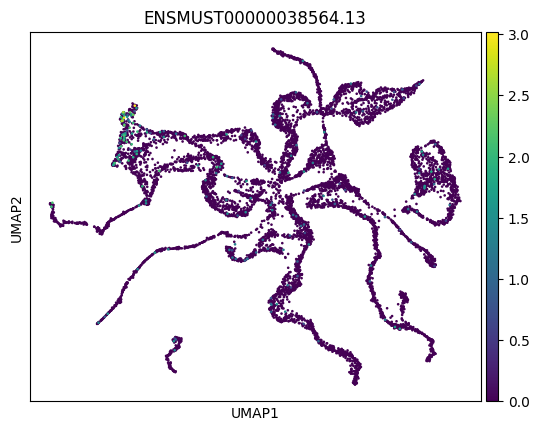

In [57]:
sc.pl.umap(
    adata,
    color=isoforms_1
)

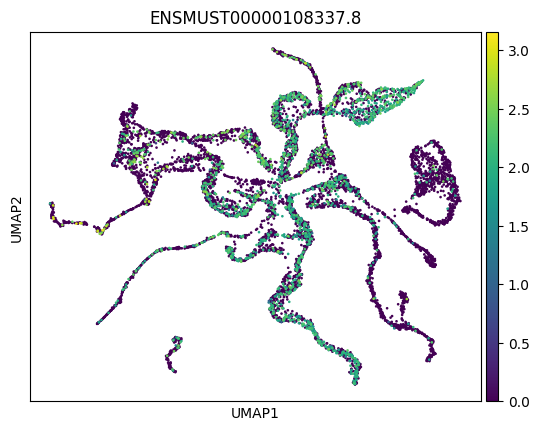

In [60]:
sc.pl.umap(
    adata,
    color=isoforms_2
)

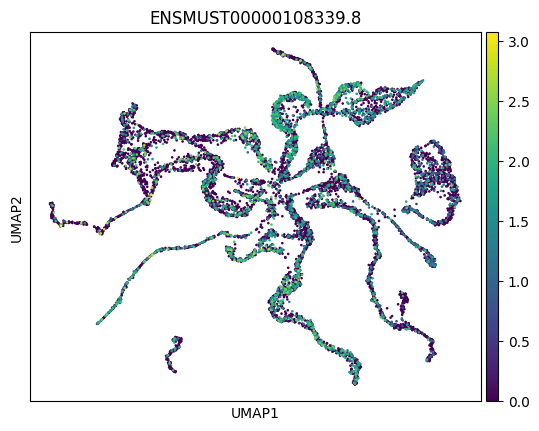

In [61]:
sc.pl.umap(
    adata,
    color=isoforms_3
)

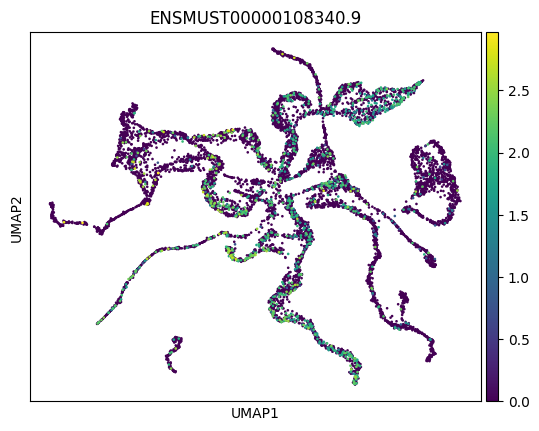

In [62]:
sc.pl.umap(
    adata,
    color=isoforms_4
)

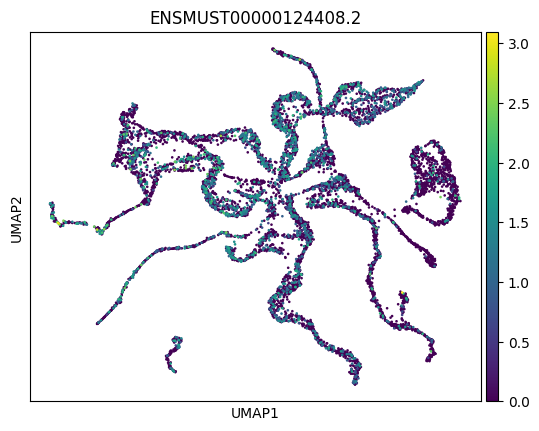

In [63]:
sc.pl.umap(
    adata,
    color=isoforms_5
)

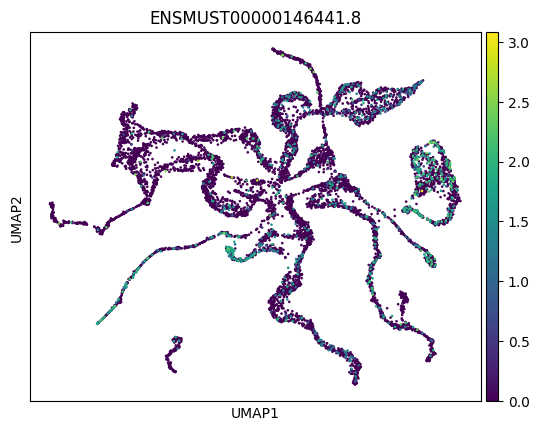

In [64]:
sc.pl.umap(
    adata,
    color=isoforms_6
)

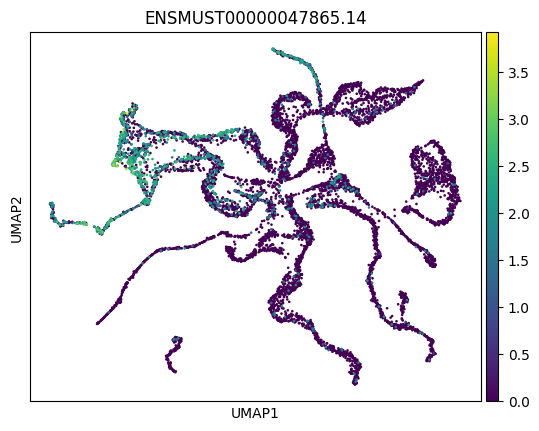

In [6]:
sc.pl.umap(
    adata,
    color=isoforms_7
)

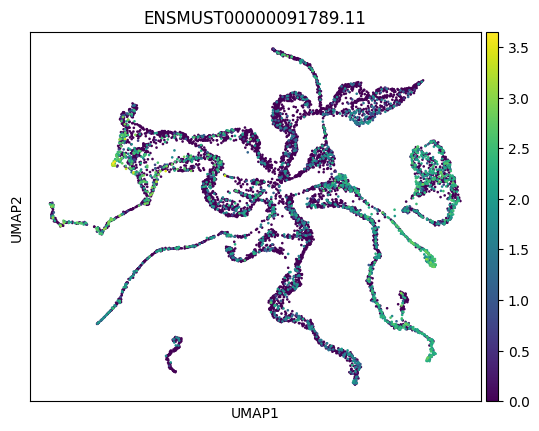

In [9]:
sc.pl.umap(
    adata,
    color=isoforms_8
)

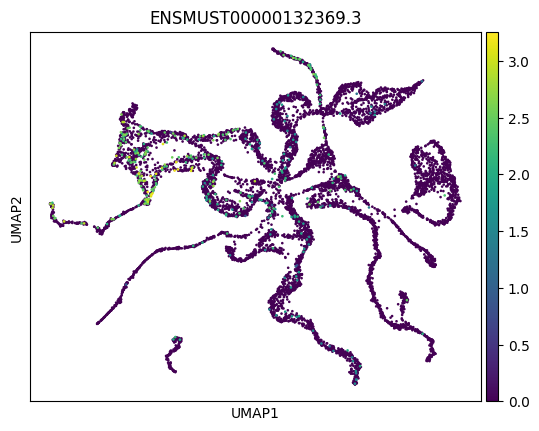

In [10]:
sc.pl.umap(
    adata,
    color=isoforms_9
)